In [1]:
### Target: County-Level hourly MW

In [2]:
!pip install shap

In [3]:
!pip install pandas pyarrow

In [4]:
!pip install lightgbm

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns  # for nicer plots
sns.set(style="darkgrid")  # default style
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import lightgbm as lgb

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [36]:
# Read in the data
def read_file(filename):
    directory = '/content/drive/My Drive/210_capstone/final_datasets/train_rolling_windows/'
    location = directory + filename+'.parquet'
    df = pd.read_parquet(location)
    return df

In [8]:
## Read in data
df=read_file('train_window_1')
df.columns

Index(['date', 'county', 'cdd65', 'cdd65_pop', 'cdd75', 'cdd75_pop',
       'cloud_cover_pct_mean', 'cloud_cover_pct_pop', 'dpt_afternoon_k_mean',
       'dpt_afternoon_k_pop', 'dpt_morning_k_mean', 'dpt_morning_k_pop',
       'hdd65', 'hdd65_pop', 'spfh_peak_kgkg_mean', 'spfh_peak_kgkg_pop',
       'tavg_k', 'tmax_k', 'tmax_k_pop', 'tmin_k', 'tmin_k_pop', 'trange_k',
       'wind_low_ms_mean', 'wind_low_ms_pop', 'wind_peak_ms_mean',
       'wind_peak_ms_pop', 'real_data_urma', 'staying_total', 'entering_total',
       'leaving_total', 'real_data_commuting', 'cuml_count', 'cuml_sq_foot',
       'cuml_utility_cap', 'cuml_dc_load', 'real_data_data_centers',
       'electricity_usage', 'public_level_1', 'shared_private_level_1',
       'public_level_2', 'shared_private_level_2', 'public_dc_fast',
       'shared_private_dc_fast', 'total', 'real_data_ev_charging', 'bev',
       'phev', 'fcev', 'real_data_ev_poplution', 'est_median_income',
       'real_data_income', 'total_pop', 'household_

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42398 entries, 0 to 42397
Data columns (total 70 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    42398 non-null  datetime64[ns]
 1   county                  42398 non-null  object        
 2   cdd65                   42398 non-null  float32       
 3   cdd65_pop               42398 non-null  float32       
 4   cdd75                   42398 non-null  float32       
 5   cdd75_pop               42398 non-null  float32       
 6   cloud_cover_pct_mean    42398 non-null  float32       
 7   cloud_cover_pct_pop     42398 non-null  float32       
 8   dpt_afternoon_k_mean    42398 non-null  float32       
 9   dpt_afternoon_k_pop     42398 non-null  float32       
 10  dpt_morning_k_mean      42398 non-null  float32       
 11  dpt_morning_k_pop       42398 non-null  float32       
 12  hdd65                   42398 non-null  float3

In [10]:
## Fix DataTypes
df['date']=pd.to_datetime(df['date'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42398 entries, 0 to 42397
Data columns (total 70 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    42398 non-null  datetime64[ns]
 1   county                  42398 non-null  object        
 2   cdd65                   42398 non-null  float32       
 3   cdd65_pop               42398 non-null  float32       
 4   cdd75                   42398 non-null  float32       
 5   cdd75_pop               42398 non-null  float32       
 6   cloud_cover_pct_mean    42398 non-null  float32       
 7   cloud_cover_pct_pop     42398 non-null  float32       
 8   dpt_afternoon_k_mean    42398 non-null  float32       
 9   dpt_afternoon_k_pop     42398 non-null  float32       
 10  dpt_morning_k_mean      42398 non-null  float32       
 11  dpt_morning_k_pop       42398 non-null  float32       
 12  hdd65                   42398 non-null  float3

## NAN Analysis

In [12]:
# Count nulls per column
null_counts = df.isna().sum().sort_values(ascending=False)

# Show only columns with nulls
null_counts[null_counts > 0]


,0
holiday,41180
shared_private_level_2,26448
real_data_ev_charging,26448
total,26448
public_level_1,26448
public_level_2,26448
public_dc_fast,26448
shared_private_dc_fast,26448
shared_private_level_1,26448


In [13]:
null_percent = (df.isna().mean() * 100).sort_values(ascending=False)

null_percent[null_percent > 0]


,0
holiday,97.127223
shared_private_level_2,62.380301
real_data_ev_charging,62.380301
total,62.380301
public_level_1,62.380301
public_level_2,62.380301
public_dc_fast,62.380301
shared_private_dc_fast,62.380301
shared_private_level_1,62.380301


In [14]:
df[df["date"].isna()].head(10)


,date,county,cdd65,cdd65_pop,cdd75,cdd75_pop,cloud_cover_pct_mean,cloud_cover_pct_pop,dpt_afternoon_k_mean,dpt_afternoon_k_pop,...,occupied,real_data_population,area,year,month,day_of_year,day_of_week,quarter,holiday,is_holiday


In [15]:
null_counts = (df.groupby("county")["electricity_usage"].apply(lambda x: x.isna().sum()).sort_values(ascending=False))

null_counts[null_counts > 0].sort_values(ascending=False)


,electricity_usage
county,


## Feature Store

In [16]:
train_1 = read_file('train_window_1')
train_2 = read_file('train_window_2')
val_1 = read_file('val_window_1')
val_2 = read_file('val_window_2')

print("train_1:", train_1.shape)
print("train_2:", train_2.shape)
print("val_1:", val_1.shape)
print("val_2:", val_2.shape)


train_1: (42398, 70)
train_2: (42398, 70)
val_1: (21170, 70)
val_2: (21170, 70)


In [17]:
# normalize target by population
for d in [train_1, train_2, val_1, val_2]:
    d['date'] = pd.to_datetime(d['date'])
    d['elec_per_capita'] = d['electricity_usage'] / d['total_pop']

    d['elec_per_capita'] = d['electricity_usage'] / d['total_pop']
    d['elec_per_capita_log'] = np.log(d['elec_per_capita'])  # add this

print("train_1:", train_1.shape)
print("elec_per_capita sample:", train_1['elec_per_capita'].describe())

train_1: (42398, 72)
elec_per_capita sample: count    42398.000000
mean         0.018993
std          0.003340
min          0.010058
25%          0.016700
50%          0.018065
75%          0.020905
max          0.040170
Name: elec_per_capita, dtype: float64


## Identify Target, Categorical and Cols on full dataset

In [18]:
selected_features = [
    # CATEGORICAL
    "county",
    "day_of_week",

    # CALENDAR
    "quarter",
    "month",
    "is_holiday",

    # TEMPERATURE
    "tmax_k_pop",
    "tmin_k_pop",
    "trange_k",

    # DEGREE DAYS
    "hdd65_pop",
    "cdd65_pop",
    "cdd75_pop",

    # ROLLING WEATHER
    "cdd65_pop_roll5",
    "hdd65_pop_roll5",
    "cdd65_pop_roll14",   # new
    "hdd65_pop_roll14",   # new
    "tmax_k_pop_roll5_max",
    "tmax_k_pop_roll7_mean",

    # HUMIDITY
    "spfh_peak_kgkg_pop",

    # WIND
    "wind_peak_ms_pop",

    # MOBILITY (fixed at 2019 baseline)
    "staying_total",
    "entering_total",
    "leaving_total",

    # DATA CENTERS
    "cuml_count",
    "cuml_sq_foot",
    "cuml_dc_load",

    # EVs (drop fcev — spurious)
    "bev",
    "phev",

    # SOCIOECONOMIC
    "est_median_income",
    "total_pop",
]

target = "elec_per_capita_log"
cat_cols = ["county", "day_of_week"]

print(f"Features: {len(selected_features)}")
print(f"Target: {target}")

Features: 29
Target: elec_per_capita_log


## Light GBM Categorical Variables

## Feature Engineering

In [19]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [20]:
ROLLING_SPECS = [
    ("cdd65_pop_roll5",      "cdd65_pop",  5,  "sum"),
    ("hdd65_pop_roll5",      "hdd65_pop",  5,  "sum"),
    ("tmax_k_pop_roll5_max", "tmax_k_pop", 5,  "max"),
    ("tmax_k_pop_roll7_mean","tmax_k_pop", 7,  "mean"),
    ("cdd65_pop_roll14",     "cdd65_pop",  14, "sum"),   # new - longer heat persistence
    ("hdd65_pop_roll14",     "hdd65_pop",  14, "sum"),   # new
]

def add_rolling_features(df):
    df = df.sort_values(["county", "date"]).copy()
    g = df.groupby("county", sort=False)
    for new_col, src_col, window, agg in ROLLING_SPECS:
        df[new_col] = g[src_col].transform(
            lambda x, w=window, a=agg: getattr(x.rolling(w, min_periods=1), a)()
        )
    return df

# compute 2019 mobility baseline from train data
mobility_baseline = (
    train_1[train_1['date'].dt.year == 2019]
    .groupby(['county', 'day_of_week'])[['staying_total','entering_total','leaving_total']]
    .median()
    .reset_index()
)
print("Mobility baseline shape:", mobility_baseline.shape)
print(mobility_baseline.head())

# --- apply to all your datasets ---
datasets = {
    "train_1": train_1,
    "train_2": train_2,
    "val_1": val_1,
    "val_2": val_2,
}

for name, d in datasets.items():
    datasets[name] = add_rolling_features(d)
    print(f"{name}: added rolling cols -> shape={datasets[name].shape}")

# overwrite your variables (optional convenience)
train_1 = datasets["train_1"]
train_2 = datasets["train_2"]
val_1   = datasets["val_1"]
val_2   = datasets["val_2"]


Mobility baseline shape: (406, 5)
    county day_of_week  staying_total  entering_total  leaving_total
0  Alameda      Friday  371037.000000   434023.000000  437366.000000
1  Alameda      Monday  371025.361644   433982.726027  437432.427397
2  Alameda    Saturday  371033.120548   434009.575342  437388.142466
3  Alameda      Sunday  371029.241096   433996.150685  437410.284932
4  Alameda    Thursday  371040.879452   434036.424658  437343.857534
train_1: added rolling cols -> shape=(42398, 78)
train_2: added rolling cols -> shape=(42398, 78)
val_1: added rolling cols -> shape=(21170, 78)
val_2: added rolling cols -> shape=(21170, 78)


In [21]:
datasets = {'train_1': train_1, 'train_2': train_2, 'val_1': val_1, 'val_2': val_2}

for name, df in datasets.items():
    df = df.drop(columns=['staying_total', 'entering_total', 'leaving_total'])
    df = df.merge(mobility_baseline, on=['county', 'day_of_week'], how='left')
    datasets[name] = df
    print(f"{name}: {df.shape} — mobility NaNs: {df[['staying_total','entering_total','leaving_total']].isnull().sum().sum()}")

train_1 = datasets['train_1']
train_2 = datasets['train_2']
val_1   = datasets['val_1']
val_2   = datasets['val_2']

train_1: (42398, 78) — mobility NaNs: 0
train_2: (42398, 78) — mobility NaNs: 0
val_1: (21170, 78) — mobility NaNs: 0
val_2: (21170, 78) — mobility NaNs: 0


In [22]:
cat_cols = ["county", "day_of_week"]

def set_and_align_categories(train_df, val_df, cat_cols=cat_cols):
    for c in cat_cols:
        if c in train_df.columns and c in val_df.columns:
            train_df[c] = train_df[c].astype("category")
            val_df[c]   = val_df[c].astype("category")
            # align val categories to train categories
            val_df[c] = val_df[c].cat.set_categories(train_df[c].cat.categories)
    return train_df, val_df


In [23]:
def set_and_align_categories(train_df, val_df, cat_cols=cat_cols):
    for c in cat_cols:
        train_df[c] = train_df[c].astype("category")
        val_df[c]   = val_df[c].astype("category")
        val_df[c]   = val_df[c].cat.set_categories(train_df[c].cat.categories)
    return train_df, val_df

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def run_window(train_df, val_df, features, params):
    X_train = train_df[features]
    y_train = train_df[target]
    X_val   = val_df[features]
    y_val   = val_df[target]

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )

    preds = model.predict(X_val, num_iteration=model.best_iteration_)
    score = rmse(y_val, preds)
    return model, score, preds, model.best_iteration_

params = dict(
    n_estimators=5000,
    learning_rate=0.01,       # slowed down from 0.03
    num_leaves=64,
    min_child_samples=50,     # regularize — prevents overfitting small counties
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

train_1, val_1 = set_and_align_categories(train_1, val_1)
train_2, val_2 = set_and_align_categories(train_2, val_2)

model1, rmse1, preds1, it1 = run_window(train_1, val_1, selected_features, params)
model2, rmse2, preds2, it2 = run_window(train_2, val_2, selected_features, params)

print(f"""
rmse_window_1 (per capita): {rmse1:.6f}
rmse_window_2 (per capita): {rmse2:.6f}
avg_rmse:                   {(rmse1+rmse2)/2:.6f}
best_iters:                 ({it1}, {it2})
""")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.026620 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6204
[LightGBM] [Info] Number of data points in the train set: 42398, number of used features: 29
[LightGBM] [Info] Start training from score -3.978016
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006886 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6204
[LightGBM] [Info] Number of data points in the train set: 42398, number of used features: 29
[LightGBM] [Info] Start training from score -3.962446

rmse_window_1 (per capita): 0.122449
rmse_window_2 (per capita): 0.132402
avg_rmse:                   0.127426
best_iters:                 (328, 138)



In [24]:
# convert per-capita predictions back to MWh (exp to undo log transform first)
val_1['preds_mwh'] = np.exp(preds1) * val_1['total_pop']
val_2['preds_mwh'] = np.exp(preds2) * val_2['total_pop']

def rmse_mwh(df):
    return np.sqrt(mean_squared_error(df['electricity_usage'], df['preds_mwh']))

def pct_of_mean(df):
    return 100 * rmse_mwh(df) / df['electricity_usage'].mean()

def pop_weighted_rmse_pct(df):
    w = df['total_pop'].values
    wrmse = np.sqrt(np.sum(w * (df['electricity_usage'] - df['preds_mwh'])**2) / np.sum(w))
    wmean = np.average(df['electricity_usage'], weights=w)
    return 100 * wrmse / wmean

print("=== NEW MODEL ===")
print(f"RMSE MWh  w1: {rmse_mwh(val_1):,.0f}   w2: {rmse_mwh(val_2):,.0f}   avg: {(rmse_mwh(val_1)+rmse_mwh(val_2))/2:,.0f}")
print(f"RMSE % mean  w1: {pct_of_mean(val_1):.1f}%  w2: {pct_of_mean(val_2):.1f}%")
print(f"Pop-wtd RMSE% w1: {pop_weighted_rmse_pct(val_1):.1f}%  w2: {pop_weighted_rmse_pct(val_2):.1f}%")

print("\n=== OLD MODEL (for reference) ===")
print(f"RMSE MWh avg: 4,885")
print(f"RMSE % mean: 37.6%")
print(f"Pop-wtd RMSE%: 21.9%")

=== NEW MODEL ===
RMSE MWh  w1: 3,617   w2: 3,916   avg: 3,766
RMSE % mean  w1: 27.7%  w2: 29.1%
Pop-wtd RMSE% w1: 16.4%  w2: 17.2%

=== OLD MODEL (for reference) ===
RMSE MWh avg: 4,885
RMSE % mean: 37.6%
Pop-wtd RMSE%: 21.9%


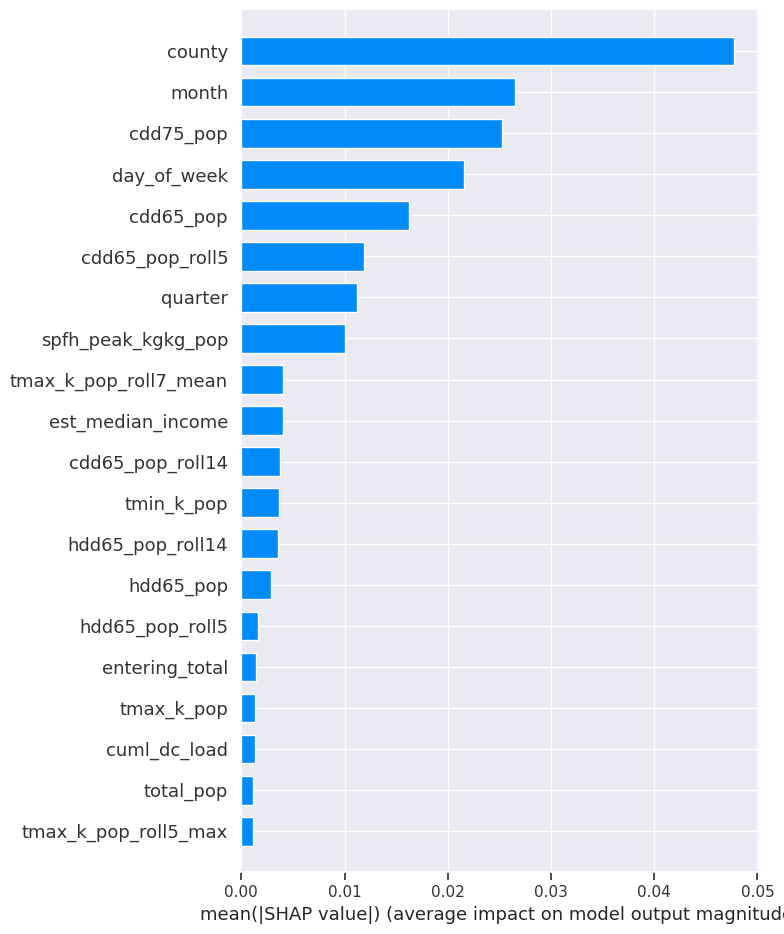

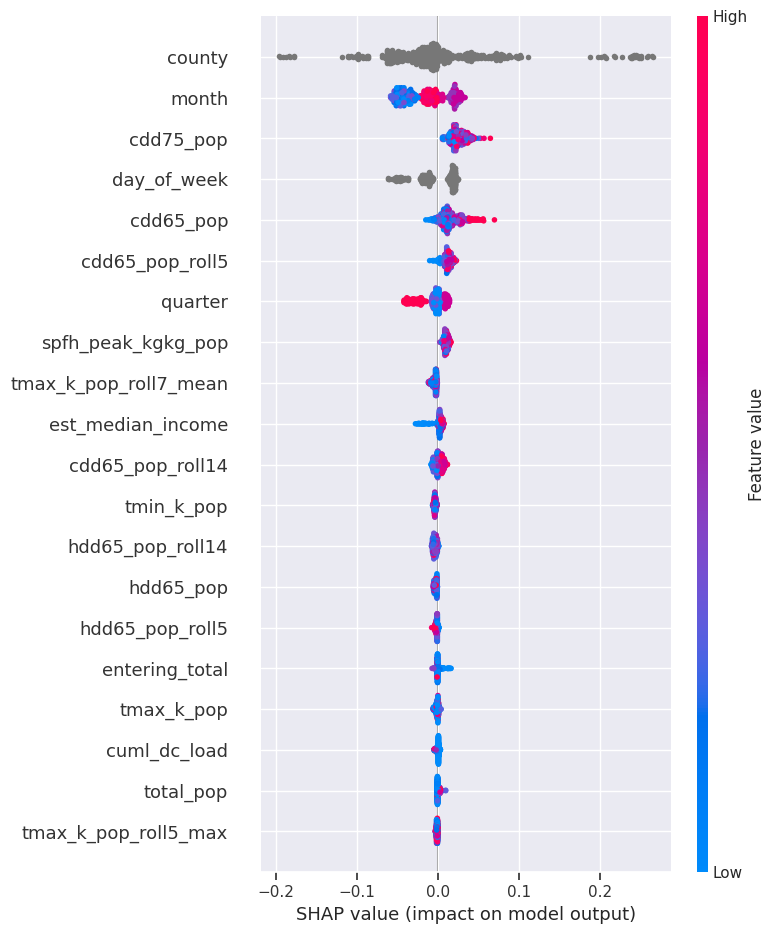

In [25]:
import shap

explainer = shap.TreeExplainer(model1)
shap_sample = val_1[selected_features].sample(500, random_state=42)
shap_values = explainer.shap_values(shap_sample)

shap.summary_plot(shap_values, shap_sample, plot_type="bar")
shap.summary_plot(shap_values, shap_sample)

In [26]:
#!pip install mlflow

In [27]:
import mlflow
import mlflow.lightgbm
import joblib, os, tempfile
from datetime import datetime

run_ts = datetime.now().strftime('%Y%m%d_%H%M')
model_version = 'v2'
model_name = f'lgbm_{target}_{model_version}_{run_ts}'

MODEL_DIR = '/content/drive/My Drive/210_capstone/models'
PRED_DIR  = '/content/drive/My Drive/210_capstone/predictions'
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PRED_DIR,  exist_ok=True)

mlflow.set_tracking_uri(f'sqlite:///{MODEL_DIR}/mlflow.db')
mlflow.set_experiment('climate-feat-lgbm')

with mlflow.start_run(run_name=f'lgbm_v2_{target}'):

    # ── Params ────────────────────────────────────────────────────────────
    mlflow.log_params(params)
    mlflow.log_param('target', target)
    mlflow.log_param('n_features', len(selected_features))
    mlflow.log_param('best_iter_w1', it1)
    mlflow.log_param('best_iter_w2', it2)
    mlflow.log_param('run_ts', run_ts)

    # ── Log-space RMSE (training signal) ──────────────────────────────────
    mlflow.log_metric('rmse_log_w1', rmse1)
    mlflow.log_metric('rmse_log_w2', rmse2)
    mlflow.log_metric('rmse_log_avg', (rmse1 + rmse2) / 2)

    # ── MWh metrics (primary electricity output metrics) ──────────────────
    rmse_mwh_w1 = rmse_mwh(val_1)
    rmse_mwh_w2 = rmse_mwh(val_2)
    mlflow.log_metric('rmse_mwh_w1',  rmse_mwh_w1)
    mlflow.log_metric('rmse_mwh_w2',  rmse_mwh_w2)
    mlflow.log_metric('rmse_mwh_avg', (rmse_mwh_w1 + rmse_mwh_w2) / 2)
    mlflow.log_metric('rmse_pct_mean_w1',    pct_of_mean(val_1))
    mlflow.log_metric('rmse_pct_mean_w2',    pct_of_mean(val_2))
    mlflow.log_metric('pop_wtd_rmse_pct_w1', pop_weighted_rmse_pct(val_1))
    mlflow.log_metric('pop_wtd_rmse_pct_w2', pop_weighted_rmse_pct(val_2))

    # ── Log models to MLflow ──────────────────────────────────────────────
    mlflow.lightgbm.log_model(model1, artifact_path='lgbm_w1')
    mlflow.lightgbm.log_model(model2, artifact_path='lgbm_w2')

    # ── Feature list as artifact ──────────────────────────────────────────
    with tempfile.NamedTemporaryFile(mode='w', suffix='.txt', delete=False) as f:
        f.write('\n'.join(selected_features))
        tmp = f.name
    mlflow.log_artifact(tmp, artifact_path='metadata')
    os.unlink(tmp)

    print(f'MLflow run logged — climate-feat-lgbm / {model_name}')
    print(f'  rmse_mwh_avg:        {(rmse_mwh_w1+rmse_mwh_w2)/2:,.0f} MWh')
    print(f'  pop_wtd_rmse_pct w1: {pop_weighted_rmse_pct(val_1):.1f}%')
    print(f'  pop_wtd_rmse_pct w2: {pop_weighted_rmse_pct(val_2):.1f}%')

# ── Export models + inference artifacts for ensemble ─────────────────────────
joblib.dump(model1, f'{MODEL_DIR}/{model_name}_w1.pkl')
joblib.dump(model2, f'{MODEL_DIR}/{model_name}_w2.pkl')
joblib.dump(selected_features, f'{MODEL_DIR}/{model_name}_features.pkl')
mobility_baseline.to_parquet(f'{MODEL_DIR}/mobility_baseline_2019.parquet')

# Save val predictions (log-space + MWh) for ensemble stacking
val_1['elec_per_capita_log_actual'] = val_1[target]
val_1['elec_per_capita_log_pred']   = preds1
val_2['elec_per_capita_log_actual'] = val_2[target]
val_2['elec_per_capita_log_pred']   = preds2

pred_cols = ['county', 'date', 'total_pop', 'electricity_usage',
             'elec_per_capita_log_actual', 'elec_per_capita_log_pred', 'preds_mwh']

val_1[pred_cols].to_parquet(f'{PRED_DIR}/{model_name}_preds_w1.parquet', index=False)
val_2[pred_cols].to_parquet(f'{PRED_DIR}/{model_name}_preds_w2.parquet', index=False)

print('\nExported for ensemble:')
print(f'  {model_name}_w1.pkl / _w2.pkl')
print(f'  {model_name}_features.pkl')
print(f'  mobility_baseline_2019.parquet')
print(f'  {model_name}_preds_w1.parquet  (log pred + MWh)')
print(f'  {model_name}_preds_w2.parquet  (log pred + MWh)')

2026/02/23 20:08:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/23 20:08:08 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/02/23 20:08:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/23 20:08:18 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MLflow run logged — climate-feat-lgbm / lgbm_elec_per_capita_log_v2_20260223_2008
  rmse_mwh_avg:        3,766 MWh
  pop_wtd_rmse_pct w1: 16.4%
  pop_wtd_rmse_pct w2: 17.2%

Exported for ensemble:
  lgbm_elec_per_capita_log_v2_20260223_2008_w1.pkl / _w2.pkl
  lgbm_elec_per_capita_log_v2_20260223_2008_features.pkl
  mobility_baseline_2019.parquet
  lgbm_elec_per_capita_log_v2_20260223_2008_preds_w1.parquet  (log pred + MWh)
  lgbm_elec_per_capita_log_v2_20260223_2008_preds_w2.parquet  (log pred + MWh)


In [33]:
import mlflow
import subprocess
from pyngrok import ngrok, conf
import getpass


In [34]:
# Define the MLflow tracking URI with SQLite
MLFLOW_TRACKING_URI = "sqlite:///mlflow.db"

# Start the MLflow server using subprocess
subprocess.Popen(["mlflow", "ui", "--backend-store-uri", MLFLOW_TRACKING_URI, "--port", "5000"])

<Popen: returncode: None args: ['mlflow', 'ui', '--backend-store-uri', 'sqli...>

# IDK OLD BELOW

In [ ]:
# def run_window(train_df, val_df, selected_features, params):

#     X_train = train_df[selected_features]
#     y_train = train_df[target]
#     X_val   = val_df[selected_features]
#     y_val   = val_df[target]

#     model = lgb.LGBMRegressor(**params)

#     model.fit(
#         X_train, y_train,
#         eval_set=[(X_val, y_val)],
#         eval_metric="rmse",
#         callbacks=[lgb.early_stopping(50, verbose=False)]
#     )

#     preds = model.predict(X_val, num_iteration=model.best_iteration_)
#     score = rmse(y_val, preds)

#     return model, score, model.best_iteration_

# params = dict(
#     n_estimators=5000,
#     learning_rate=0.03,
#     num_leaves=64,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
# )

In [ ]:
!mlflow ui --port 5000 &
from google.colab.output import eval_js
print(eval_js("google.colab.kernel.proxyPort(5000)"))

In [ ]:
def weighted_rmse(y_true, y_pred, weights):
    return np.sqrt(np.sum(weights * (y_true - y_pred) ** 2) / np.sum(weights))


In [ ]:
import numpy as np

def weighted_rmse(y_true, y_pred, weights):
    weights = np.asarray(weights)
    return np.sqrt(np.sum(weights * (y_true - y_pred) ** 2) / np.sum(weights))

preds1 = model1.predict(
    val_1[selected_features],
    num_iteration=model1.best_iteration_
)

w_rmse1 = weighted_rmse(
    val_1["electricity_usage"].values,
    preds1,
    val_1["total_pop"].values
)

print("Population-weighted RMSE (window 1):", w_rmse1)


In [ ]:
preds2 = model2.predict(
    val_2[selected_features],
    num_iteration=model2.best_iteration_
)

w_rmse2 = weighted_rmse(
    val_2["electricity_usage"].values,
    preds2,
    val_2["total_pop"].values
)

print("Population-weighted RMSE (window 2):", w_rmse2)
print("Avg population-weighted RMSE:", (w_rmse1 + w_rmse2)/2)


In [ ]:
w_mean_load_1 = np.average(val_1["electricity_usage"].values, weights=val_1["total_pop"].values)
print("Pop-weighted mean load (w1):", w_mean_load_1)
print("Pop-weighted RMSE % (w1):", 100 * w_rmse1 / w_mean_load_1)


## OLD Split into Test/Train/Val

In [ ]:
## Rolling Window Cols

# Sort first (critical)
df = df.sort_values(["county", "date"])

df["cdd65_pop_roll5"] = (
    df.groupby("county")["cdd65_pop"]
      .transform(lambda x: x.rolling(5, min_periods=1).sum())
)

df["hdd65_pop_roll5"] = (
    df.groupby("county")["hdd65_pop"]
      .transform(lambda x: x.rolling(5, min_periods=1).sum())
)

df["tmax_k_pop_roll5_max"] = (
    df.groupby("county")["tmax_k_pop"]
      .transform(lambda x: x.rolling(window=5, min_periods=1).max())
)

df["tmax_k_pop_roll3_mean"] = (
    df.groupby("county")["tmax_k_pop"]
      .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
)

df["tmax_k_pop_roll7_mean"] = (
    df.groupby("county")["tmax_k_pop"]
      .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
)

df["tmax_k_pop_roll3_max"] = (
    df.groupby("county")["tmax_k_pop"]
      .transform(lambda x: x.rolling(3, min_periods=1).max())
)

df["tmax_k_pop_roll7_max"] = (
    df.groupby("county")["tmax_k_pop"]
      .transform(lambda x: x.rolling(7, min_periods=1).max())
)

In [ ]:
# train_end = pd.Timestamp("2018-09-01")
# val_end   = pd.Timestamp("2018-11-01")

# df = df.sort_values(["date"] + [c for c in "county" if c in df.columns])


# train_df = df[df["date"] < train_end]
# val_df   = df[(df["date"] >= train_end) & (df["date"] < val_end)]
# test_df  = df[df["date"] >= val_end]


In [ ]:
# train_shape = train_df.shape
# val_shape = val_df.shape
# test_shape =test_df.shape
# print(f"Shapes:\nTrain:{train_shape}\nVal:{val_shape}\nTest:{test_shape}\n")

In [ ]:
## Remove target cols and date cols (not useful for lightGBM)
df = df.copy() ## copy